In [1]:
import MDAnalysis as mda
import freud
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.interpolate import CubicSpline

In [2]:
def get_max_nematic_order(top_file, traj_file):

    u = mda.Universe(top_file, format="DATA", atom_style="id resid type charge x y z")
    u.load_new(traj_file, format="LAMMPSDUMP", dt=1.0)

    nematic = freud.order.Nematic()

    S_lst = []

    for frame_id, frame in enumerate(u.trajectory):

        mol_positions = []
        for mol in u.residues:
            if len(mol.atoms) == 12:
                mol_positions.append(mol.atoms.positions.copy())

        box_dims = u.dimensions[:3]
        for i, mol in enumerate(mol_positions):
            ref = mol[0]
            delta = mol - ref
            delta = delta - box_dims * np.round(delta/box_dims)
            mol_positions[i] = ref + delta

        orientations = []
        for mol in mol_positions:
            head = mol[0]
            tail = (mol[7] + mol[11]) / 2
            vec = tail - head
            orientations.append(vec / np.linalg.norm(vec))

        nematic.compute(np.array(orientations))
        S = nematic.order

        S_lst.append(S)


    return S_lst


In [3]:
dir = "/home/gabriel/Dokumente/bachelor_thesis/dpd_simulation/lipid_self_assembly/"

wl_str = ["8", "10", "12", "14", "16", "18", "20", "22", "24", "26", "28", "30"]

trajectories = []

for wl in wl_str:
    trajectories.append((f"setup/bilayers/bilayer_wl_{wl}.data", f"water_per_lipid_opt/trajs_T_1/bilayer_wl_{wl}.lammpstrj"))

In [4]:
results = []

for top, traj in trajectories:
    top_path = os.path.join(dir, top)
    traj_path = os.path.join(dir, traj)

    s_lst = get_max_nematic_order(top_path, traj_path)

    results.append(s_lst)

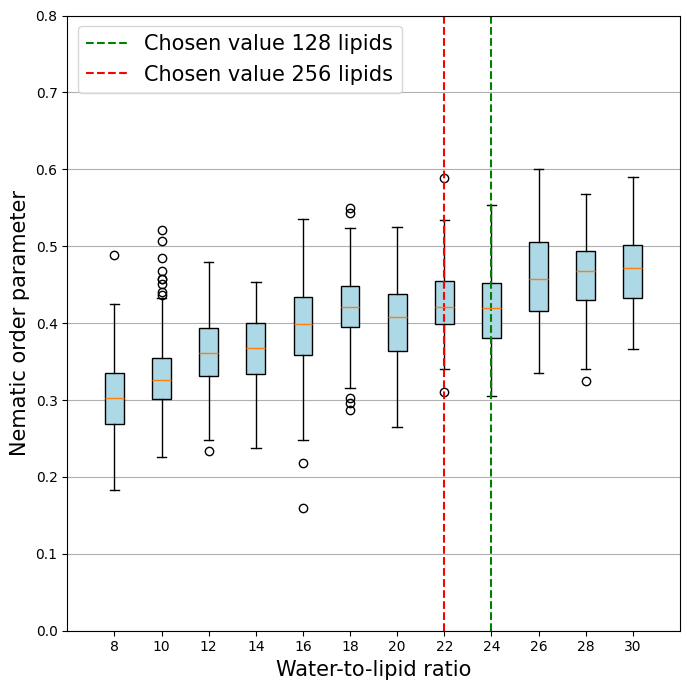

In [6]:
wls = [8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]

plt.figure(figsize=(7,7))

bp = plt.boxplot(results, positions=wls, widths=0.8, patch_artist=True)

for patch in bp['boxes']:
    patch.set_facecolor('lightblue')

plt.axvline(24, linestyle='dashed', color='green', label='Chosen value 128 lipids')
plt.axvline(22, linestyle='dashed', color='red', label='Chosen value 256 lipids')
plt.xlabel("Water-to-lipid ratio", fontsize=15)
plt.ylabel("Nematic order parameter", fontsize=15)
plt.xlim((6,32))
plt.ylim((0,0.8))
plt.tight_layout()
plt.grid(axis='y')
plt.legend(fontsize=15, frameon=True)
plt.show()